# Faculdade de Informática e Administração Paulista(FIAP)
POSTECH Data Analytics - BB 

---
Disciplina: Fase 5 - Deep Learning and unstructured data  \
Turma: 1DTAT BB  - Período: 13/01/2026 à 31/03/2026  

1 - Desafio 

#### TECH CHALLENGE
Tech Challenge é o projeto que engloba os conhecimentos obtidos em
todas as disciplinas da fase. Esta é uma atividade que, a princípio, deve ser
desenvolvida em grupo. Importante atentar-se ao prazo de entrega, pois trata-se
de uma atividade obrigatória, uma vez que sua pontuação se refere a 90% da
nota final.

##### O problema: Classificação de Reclamações Financeiras e Análise das Dores dos Clientes. 
Nesse Tech Challenge você tem o desafio de construir um modelo de
Deep Learning capaz de classificar automaticamente o sentimento das
reclamações de clientes (positivas ou negativas) com base no texto enviado,
e realizar uma análise das principais dores relatadas em cada categoria de
produto financeiro.

Você tem em mãos um conjunto de dados com reclamações de
consumidores sobre produtos e serviços financeiros, contendo o texto da
reclamação, a empresa envolvida e a categoria do produto/serviço (como cartão
de crédito, hipoteca, empréstimo, etc.). Essas reclamações foram encaminhadas
às empresas e publicadas após confirmação de relacionamento comercial.
Agora, sua missão é ajudar a entender melhor como os consumidores se
sentem em relação a esses serviços e quais problemas são mais recorrentes.



##### Dados
Utilize os dados disponíveis em https://cfpb.github.io/api/ccdb/index.html. 
Pode ser utilizado os dados do https://www.kaggle.com/datasets/shashwatwork/consume-complaints-dataset-fo-nlp que tem um tamanho menor, conforme orientação 
da Ana Raquel em live. 


##### Requisitos de entrega

Pré-processamento de texto \
● Limpe os textos: remova pontuações, stopwords, aplique
lematização/stemming. \
● Considere técnicas de vetorização como TF-IDF ou Word
Embeddings (ex: CountVectorizer, TfidfVectorizer, spaCy,
BERT)

Criação da variável alvo \
Crie uma coluna sentimento classificando as reclamações como: \
● Negativa: reclamações que expressam insatisfação, erro, cobrança
indevida, etc. \
● Positiva: eventualmente, mensagens resolvidas ou com feedbacks
positivos (pode ser necessário construir regras ou usar anotações
manuais para treinar o modelo). 

Modelagem

● Treine um modelo de classificação utilizando Deep Learning. \
● Avalie a performance com métricas de validação de modelos.

Análise das Dores dos Clientes

● Gere visualizações (nuvem de palavras, gráfico de frequência) com os
termos mais comuns nas reclamações negativas, por categoria de
produto. \
● Identifique os principais temas de insatisfação (ex: cobrança
indevida, falha no atendimento, problemas com estorno).


#### Entregáveis

✓ Repositório do GithHub com o código com pipeline de NLP e modelo
de classificação. \
✓ Análise dos principais termos/temas negativos por categoria. \
✓ Gráficos ou visualizações que ajudem a entender o sentimento dos
clientes. \
✓ Vídeo de até 5 (cinco) minutos apresentando as principais dores e o
sentimento dos clientes nas ligações.

Não se esqueçam de que isso é um entregável obrigatório! Se atente para
o prazo de entrega até o final da fase. Caso tenha alguma dúvida no
desenvolvimento do projeto, não deixe de chamar nossos(as) professores(as)!

## Grupo: 27 - Aluno: Ederson Schmeing

---

## Aquisição dos Dados

In [ ]:
# Aquisição dos dados

!curl -L -o ~/Downloads/consume-complaints-dataset-fo-nlp.zip\
  https://www.kaggle.com/api/v1/datasets/download/shashwatwork/consume-complaints-dataset-fo-nlp


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 19.8M  100 19.8M    0     0  9532k      0  0:00:02  0:00:02 --:--:-- 12.9M
Archive:  /home/edersonschmeing/Downloads/consume-complaints-dataset-fo-nlp.zip
  inflating: complaints_processed.csv  


In [ ]:
# carrega dados.
import pandas as pd

df_reclamacoes = pd.read_csv("complaints_processed.csv")
print(df_reclamacoes.shape)
df_reclamacoes.head()

(162421, 3)


,Unnamed: 0,product,narrative
0,0,credit_card,purchase order day shipping amount receive pro...
1,1,credit_card,forwarded message date tue subject please inve...
2,2,retail_banking,forwarded message cc sent friday pdt subject f...
3,3,credit_reporting,payment history missing credit report speciali...
4,4,credit_reporting,payment history missing credit report made mis...


## Pré-processamento

In [ ]:
%pip install --upgrade nltk

In [ ]:
# Pré-processamento de texto
import re
import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')


[nltk_data] Downloading package punkt to
[nltk_data]     /home/edersonschmeing/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/edersonschmeing/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /home/edersonschmeing/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /home/edersonschmeing/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [ ]:

palavras_de_parada = stopwords.words('english')
lematizador = WordNetLemmatizer()

# Função de limpeza
def pre_processar_texto(texto):
    if not isinstance(texto, str):
        return ""
    
    texto = texto.lower()
    
    # usando expressões regulares para deixar somente texto
    texto = re.sub(r'\d+', '', texto)
    texto = re.sub(r'[^\w\s]', '', texto)

    tokens = word_tokenize(texto)

    tokens = [
        lematizador.lemmatize(palavra)
        for palavra in tokens
        if palavra not in palavras_de_parada
    ]

    return " ".join(tokens)

In [21]:
# Aplica a função de limpeza
df_reclamacoes = df_reclamacoes.dropna(subset=["narrative"])
df_reclamacoes["narrative"] = df_reclamacoes["narrative"].astype(str)
df_reclamacoes["texto_limpo"] = df_reclamacoes["narrative"].apply(pre_processar_texto)

In [22]:
df_reclamacoes.head(10)

,Unnamed: 0,product,narrative,texto_limpo
0,0,credit_card,purchase order day shipping amount receive pro...,purchase order day shipping amount receive pro...
1,1,credit_card,forwarded message date tue subject please inve...,forwarded message date tue subject please inve...
2,2,retail_banking,forwarded message cc sent friday pdt subject f...,forwarded message cc sent friday pdt subject f...
3,3,credit_reporting,payment history missing credit report speciali...,payment history missing credit report speciali...
4,4,credit_reporting,payment history missing credit report made mis...,payment history missing credit report made mis...
5,5,credit_reporting,payment history missing credit report made mis...,payment history missing credit report made mis...
6,6,credit_reporting,va date complaint experian credit bureau invol...,va date complaint experian credit bureau invol...
7,7,credit_reporting,account reported abbreviated name full name se...,account reported abbreviated name full name se...
8,8,credit_reporting,account reported abbreviated name full name se...,account reported abbreviated name full name se...
9,9,credit_reporting,usdoexxxx account reported abbreviated name fu...,usdoexxxx account reported abbreviated name fu...


In [23]:
# Criação da variável alvo (sentimento)

palavras_negativas = [
    "error", "fraud", "unauthorized", "charged",
    "complaint", "problem", "denied", "dispute",
    "incorrect", "delay", "scam", "debt"
]

palavras_positivas = [
    "resolved", "satisfied", "thank",
    "fixed", "helpful", "closed",
    "approved", "refunded"
]

def classificar_sentimento(row):
    texto = str(row["narrative"]).lower()
    
    pontuacao_negativa = sum(palavra in texto for palavra in palavras_negativas)
    pontuacao_positiva = sum(palavra in texto for palavra in palavras_positivas)


    # regras adicionais (mais inteligentes)
    if str(row.get("consumer_disputed", "")).lower() == "yes":
        return "negativo"
    
    if "closed with monetary relief" in str(row.get("company_response_to_consumer", "")).lower():
        return "positivo"

    if pontuacao_negativa > pontuacao_positiva:
        return "negativo"
    elif pontuacao_positiva > pontuacao_negativa:
        return "positivo"
    else:
        return "negativo"  # Padrão (dataset tende a negativo)


In [24]:
# Aplicar a classificar sentimento
df_reclamacoes["sentimento"] = df_reclamacoes.apply(classificar_sentimento, axis=1)
df_reclamacoes["classe"] = (df_reclamacoes["sentimento"] == "positivo").astype(int)

In [25]:
# Separar treino e teste
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df_reclamacoes["texto_limpo"],
    df_reclamacoes["classe"],
    test_size=0.2,
    stratify=df_reclamacoes["classe"],
    random_state=42
)

In [26]:
# Balanceamento parcial dos dados de treino

import pandas as pd
from sklearn.utils import resample
df_treino = pd.DataFrame({
    "texto_limpo": X_train,
    "classe": y_train
})

df_sentimento_negativo = df_treino[df_treino["classe"] == 0]
df_sentimento_positivo = df_treino[df_treino["classe"] == 1]

df_sentimento_positivo_aumentado = resample(
    df_sentimento_positivo,
    replace=True,
    n_samples=int(len(df_sentimento_negativo) * 0.7),
    random_state=42
)
df_treino_balanceado = pd.concat([df_sentimento_negativo, 
                                  df_sentimento_positivo_aumentado]).sample(frac=1)


## Modelo

In [ ]:
%pip install keras --upgrade
%pip install tensorflow

In [27]:
# Tokenização (para LSTM)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

tokenizer = Tokenizer(num_words=10000)
tokenizer.fit_on_texts(df_treino_balanceado["texto_limpo"])

X_train_seq = tokenizer.texts_to_sequences(df_treino_balanceado["texto_limpo"])
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=100)
X_test_pad = pad_sequences(X_test_seq, maxlen=100)

y_treino_balanceado = df_treino_balanceado["classe"]

I0000 00:00:1774821875.711783    5061 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1774821880.697445    5061 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [ ]:
# Classe weights (reforço), peso maior para quem tem menos amostras
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_treino_balanceado)

weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_treino_balanceado
)
class_weight = dict(zip(classes, weights))

In [51]:
#Modelo Deep Learning (LSTM)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

model = Sequential([
    Embedding(input_dim=10000, output_dim=128),
    LSTM(64),
    Dense(1, activation='sigmoid')
])

model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [30]:
# Treinamento
model.fit(
    X_train_pad,
    y_treino_balanceado,
    epochs=3,
    batch_size=32,
    validation_split=0.1,
    class_weight=class_weight
)


Epoch 1/3


W0000 00:00:1774821994.372711    5061 cpu_allocator_impl.cc:82] Allocation of 73098000 exceeds 10% of free system memory.


5711/5711 ━━━━━━━━━━━━━━━━━━━━ 1075s 187ms/step - accuracy: 0.9462 - loss: 0.1371 - val_accuracy: 0.9783 - val_loss: 0.0629
Epoch 2/3
5711/5711 ━━━━━━━━━━━━━━━━━━━━ 1128s 192ms/step - accuracy: 0.9861 - loss: 0.0414 - val_accuracy: 0.9861 - val_loss: 0.0435
Epoch 3/3
5711/5711 ━━━━━━━━━━━━━━━━━━━━ 864s 151ms/step - accuracy: 0.9936 - loss: 0.0200 - val_accuracy: 0.9926 - val_loss: 0.0256


In [33]:
# Avaliação (NO TESTE ORIGINAL!)
from sklearn.metrics import classification_report, confusion_matrix

y_pred = (model.predict(X_test_pad) > 0.5).astype(int)

print(classification_report(y_test, y_pred, target_names=["Negativo", "Positivo"]))
print(confusion_matrix(y_test, y_pred))


1016/1016 ━━━━━━━━━━━━━━━━━━━━ 28s 28ms/step
              precision    recall  f1-score   support

    Negativo       0.99      0.99      0.99     29862
    Positivo       0.88      0.87      0.87      2621

    accuracy                           0.98     32483
   macro avg       0.93      0.93      0.93     32483
weighted avg       0.98      0.98      0.98     32483

[[29540   322]
 [  344  2277]]


### Visualizações

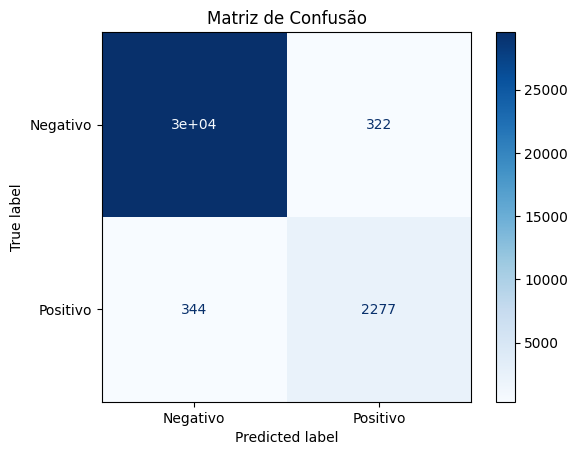

In [34]:
import matplotlib.pyplot as plt

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negativo", "Positivo"]
)

disp.plot(cmap="Blues")
plt.title("Matriz de Confusão")
plt.show()

In [35]:
#TERMOS MAIS FREQUENTES POR CATEGORIA
#Top palavras por produto

from collections import Counter

def top_words_by_category(df_reclamacoes, category_col, text_col, top_n=10):
    results = {}

    for cat in df_reclamacoes[category_col].unique():
        texts = df_reclamacoes[df_reclamacoes[category_col] == cat][text_col]
        words = " ".join(texts).split()
        freq = Counter(words)
        results[cat] = freq.most_common(top_n)

    return results
df_neg = df_reclamacoes[df_reclamacoes["classe"]==0]

top_terms = top_words_by_category(df_neg, "product", "texto_limpo")

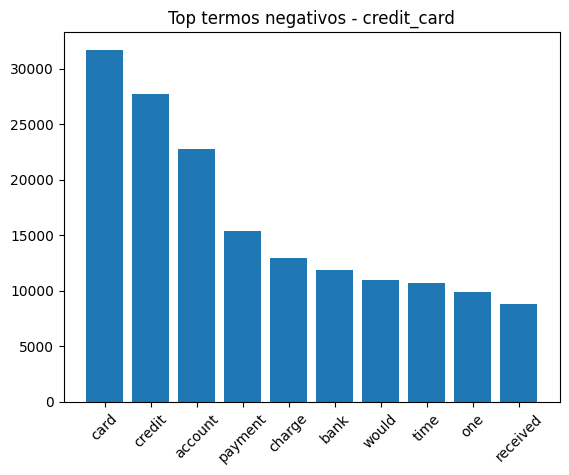

In [36]:
#Visualizar (exemplo de uma categoria)

import matplotlib.pyplot as plt

top_termos_negativos = list(top_terms.keys())[0]
palavras, quantidades = zip(*top_terms[top_termos_negativos])

plt.figure()
plt.bar(palavras, quantidades)
plt.xticks(rotation=45)
plt.title(f"Top termos negativos - {top_termos_negativos}")
plt.show()

In [37]:
%pip install wordcloud

Note: you may need to restart the kernel to use updated packages.


In [41]:
def plot_wordcloud(df, category):
    subset = df[df["product"] == category]

    if subset.empty:
        print(f"⚠️ Nenhum dado para a categoria: {category}")
        return

    text = " ".join(subset["texto_limpo"].dropna())

    if len(text.strip()) == 0:
        print(f"⚠️ Texto vazio após limpeza para: {category}")
        return

    wc = WordCloud(width=800, height=400).generate(text)
    
    plt.figure()
    plt.imshow(wc)
    plt.axis("off")
    plt.title(f"Nuvem de palavras - {category}")
    plt.show()

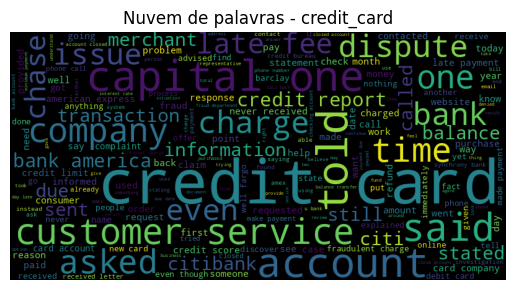

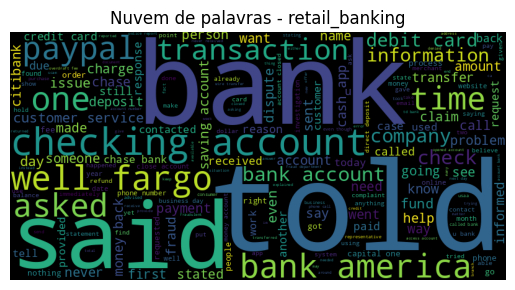

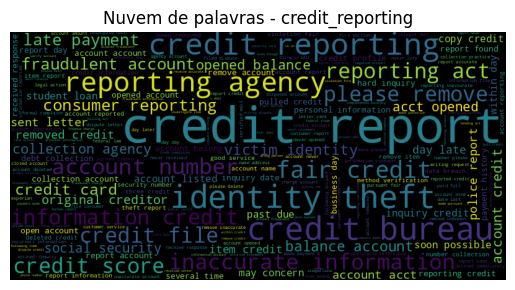

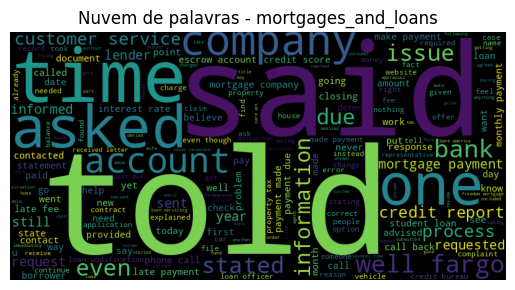

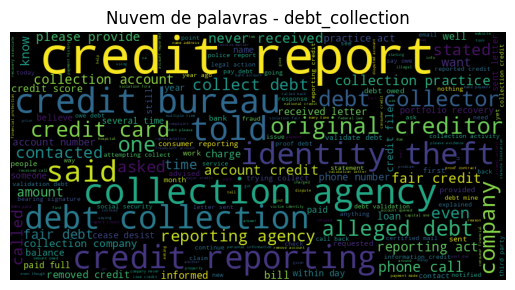

In [42]:
for cat in df_neg["product"].unique():
    plot_wordcloud(df_neg, cat)

In [45]:
themes = {
    "fraude": ["fraud", "unauthorized", "scam"],
    "cobranca indevida": ["charge", "fee", "debt", "billing"],
    "atendimento": ["service", "support", "call"],
    "estorno": ["refund", "return", "dispute"],
    "credito": ["credit", "score", "report"],
}

def detect_theme(text):
    text = text.lower()
    
    for theme, keywords in themes.items():
        if any(k in text for k in keywords):
            return theme
    
    return "outros"


df_neg = df_reclamacoes[df_reclamacoes["sentimento"] == "negativo"].copy()
df_neg["tema"] = df_neg["texto_limpo"].apply(detect_theme)

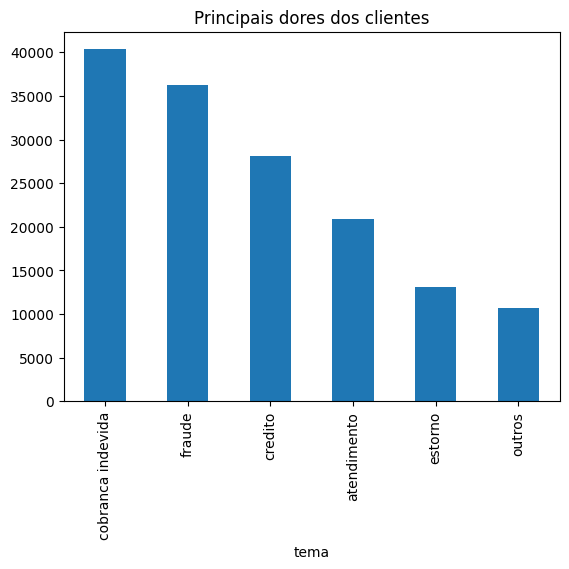

In [46]:
df_neg["tema"].value_counts().plot(kind="bar")
plt.title("Principais dores dos clientes")
plt.show()

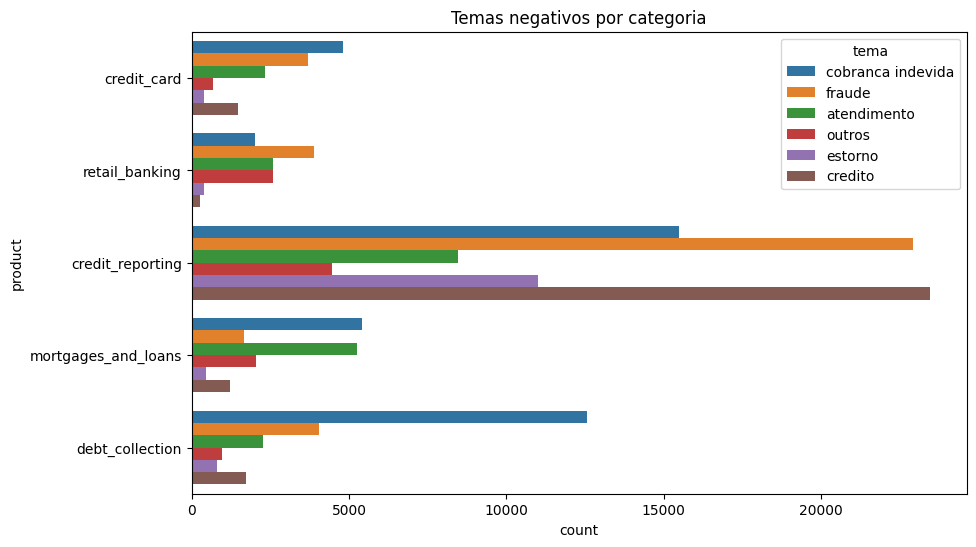

In [ ]:
import seaborn as sns

plt.figure(figsize=(10,6))
sns.countplot(data=df_neg, y="product", hue="tema")
plt.title("Temas negativos por categoria")
plt.show()

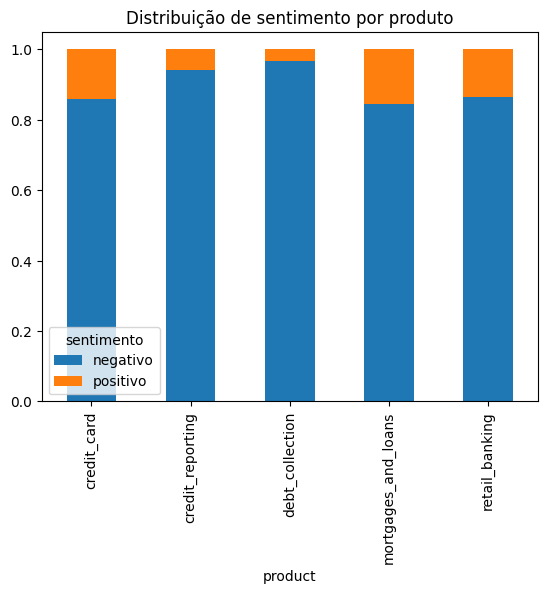

In [49]:
sentiment_by_product = df_reclamacoes.groupby("product")["sentimento"].value_counts(normalize=True).unstack()

sentiment_by_product.plot(kind="bar", stacked=True)
plt.title("Distribuição de sentimento por produto")
plt.show()

### Análise das Reclamações dos Clientes

A análise das reclamações permitiu identificar padrões relevantes de insatisfação dos clientes, tanto em termos de frequência de palavras quanto de temas recorrentes, segmentados por categoria de produto.

--- 

### 1. Principais Termos nas Reclamações Negativas

A partir das visualizações (nuvens de palavras e gráficos de frequência), observou-se que os termos mais recorrentes nas reclamações incluem:

- “charge”, “fee”, “billing”
- “fraud”, “unauthorized”, “scam”
- “credit”, “report”, “score”
- “service”, “call”, “support”

Esses termos indicam que grande parte das reclamações está relacionada a:

- cobranças indevidas
- problemas de fraude
- inconsistências em relatórios de crédito
- falhas no atendimento ao cliente

### 2. Análise por Categoria de Produto

Cartão de Crédito
- Alta incidência de termos como “unauthorized” e “fraud”
- Indica forte presença de problemas com transações não autorizadas

Empréstimos / Dívidas
- Termos como “debt”, “collection”, “payment”
- Apontam para cobranças agressivas ou inconsistentes

Relatórios de Crédito
- Frequência de “credit report”, “error”, “score”
- Indica problemas com dados incorretos ou disputas não resolvidas

Contas Bancárias
- Termos como “service”, “delay”, “support”
- Refletem falhas no atendimento e tempo de resposta

### 3. Principais Temas de Insatisfação

A classificação por temas revelou os seguintes principais grupos de problemas:

- Cobrança indevida tem o maior volume de reclamações
- Fraude tem alta criticidade (impacto financeiro direto)
- Atendimento ao cliente recorrente em várias categorias
- Estornos/Reembolsos dificuldade na resolução

### 4. Distribuição de Sentimentos

A análise da proporção de sentimentos por produto mostra que:

- A maioria das categorias apresenta predominância de sentimento negativo
- Algumas categorias específicas apresentam maior equilíbrio, 
sugerindo melhor gestão ou resolução de problemas. 


### 5. Percepções de Negócio

A partir dos resultados, destacam-se os seguintes pontos críticos:

Principais dores dos clientes:
- Cobranças indevidas e taxas inesperadas
- Falta de segurança (fraudes e transações não autorizadas)
- Baixa qualidade no atendimento
- Dificuldade em obter estornos ou resolver disputas

Oportunidades de melhoria:
- Melhorar sistemas de detecção de fraude
- Tornar processos de cobrança mais transparentes
- Investir em atendimento ao cliente (SLA, canais, treinamento)
- Automatizar e agilizar processos de reembolso


### Conclusão

A análise demonstra que as reclamações dos clientes estão concentradas em problemas operacionais e de confiança, especialmente relacionados a cobranças e segurança.

Esses resultados podem ser utilizados como base para:

- priorização de melhorias internas
- desenvolvimento de modelos preditivos de churn
- criação de dashboards de monitoramento de satisfação
